# Explicit ABBA guiding-center symplecticity study

This experiment evaluates the physical guiding-center map produced by `ExplicitABBA`. At the beginning of every step, the physical state is duplicated, $E y_n=(y_n,y_n)$. For $s=h/2$, the copies follow $A_{s,t_n}$, $B_{s,t_n}$, $B_{s,t_n+h}$, and $A_{s,t_n+h}$, and the final physical state is their arithmetic mean:

$$y_{n+1}=P\Phi^{\mathrm{ABBA}}_{h,t_n}E y_n,\qquad P(u,v)=\frac{u+v}{2}. $$

The method is explicit and second order, but $P$ is a Euclidean projection and does not guarantee symplecticity. For every complete step, the experiment differentiates the emitted physical map by centered finite differences. If $J_n$ is the local step Jacobian and $DG_n$ is the accumulated discrete-flow Jacobian, it records

$$\varepsilon_{\mathrm{local},n}=\frac{\|J_n^T\Omega J_n-\Omega\|_F}{\|\Omega\|_F},\qquad \varepsilon_{\mathrm{flow},n}=\frac{\|DG_n^T\Omega DG_n-\Omega\|_F}{\|\Omega\|_F}. $$

Transported polygon area, $|\det(DG_n)-1|$, and the pre-projection separation $\|u^{(2)}-v^{(2)}\|_\infty$ provide complementary geometric diagnostics.

In [1]:
import numpy as np

from workflows import (
    ExplicitABBASymplecticityConfig,
    RandomPotentialConfig,
    centered_circle,
    pi_area_steps,
    run_explicit_abba_symplecticity_study,
)

## Reproducible configuration

The potential, initial boundary, physical parameters, time interval, ABBA steps, observation grid, and finite-difference scale are explicit below. The random field, radius, and $\rho$ match the RK4 and symmetric-projected ABBA experiments in this directory. Eight boundary points and the interval $[0,\pi]$ keep the full step-by-step Jacobian propagation practical while retaining three temporal refinements.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

circle_radius = 0.5
circle_points = 8
rho = 0.3
circle = centered_circle(
    potential,
    radius=circle_radius,
    points=circle_points,
    rho=rho,
)

finite_difference_relative_step = float(np.cbrt(np.finfo(float).eps))
study_config = ExplicitABBASymplecticityConfig(
    steps=pi_area_steps(20, 40, 80),
    t_span=(0.0, np.pi),
    save_interval=np.pi / 10,
    chunk_size=16,
    progress=True,
    block_prefix="explicit_abba_symplecticity",
    finite_difference_relative_step=finite_difference_relative_step,
)

print(potential_config)
print(study_config)
print(
    f"Circle: {circle_points} points; t={study_config.t_span}; "
    f"{study_config.output_sample_count} saved states; "
    f"finite-difference relative step={finite_difference_relative_step:.8e}"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=25, nx=64, ny=64, seed=27, interpolation_order=5)
ExplicitABBASymplecticityConfig(steps=(AreaStep(label='$\\Delta t=\\pi/20$', value=0.15707963267948966), AreaStep(label='$\\Delta t=\\pi/40$', value=0.07853981633974483), AreaStep(label='$\\Delta t=\\pi/80$', value=0.039269908169872414)), t_span=(0.0, 3.141592653589793), save_interval=0.3141592653589793, chunk_size=16, progress=True, block_prefix='explicit_abba_symplecticity', finite_difference_relative_step=6.0554544523933395e-06)
Circle: 8 points; t=(0.0, 3.141592653589793); 11 saved states; finite-difference relative step=6.05545445e-06


In [6]:
finite_difference_relative_step

6.0554544523933395e-06

## Explicit ABBA integrations and persisted Jacobians

Every main-grid ABBA step contributes to the accumulated finite-difference Jacobian. Scalar diagnostics and full local and accumulated Jacobians are persisted at the common observation times. Shadow advances used only for output interpolation do not affect the trajectory or the diagnostic history.

In [3]:
result = run_explicit_abba_symplecticity_study(
    potential,
    circle,
    notebook_path=(
        "notebooks/experiments/symplecticity/"
        "gc_area_and_explicit_abba_symplecticity.ipynb"
    ),
    config=study_config,
    metadata={
        **potential_config.metadata(),
        "circle_radius": circle_radius,
        "study_kind": "versioned_symplecticity_experiment",
    },
)
result.print_summary()

ExplicitABBA [==============================] 100.0% (20/20, t=3.14159)
ExplicitABBA [==============================] 100.0% (40/40, t=3.14159))
ExplicitABBA [==============================] 100.0% (80/80, t=3.14159))


                  step           ExplicitABBA steps     max |area error|     max local defect      max flow defect      max |det-1|
     $\Delta t=\pi/20$                           20       1.36678868e-02       1.06369674e-06       2.38900107e-06   4.64027783e-06
     $\Delta t=\pi/40$                           40       1.37232101e-02       1.91463342e-08       8.88536101e-08   2.20605237e-07
     $\Delta t=\pi/80$                           80       1.37369504e-02       2.53123939e-10       2.69723344e-09   1.03814780e-08

Maximum off-diagonal copy separation before averaging:
  $\Delta t=\pi/20$: 4.83370287e-04
  $\Delta t=\pi/40$: 9.38302262e-05
  $\Delta t=\pi/80$: 1.28780677e-05

Empirical orders (local defect / flow defect / copy separation):
  $\Delta t=\pi/20$ -> $\Delta t=\pi/40$: 5.795875 / 4.748833 / 2.365004
  $\Delta t=\pi/40$ -> $\Delta t=\pi/80$: 6.241080 / 5.041878 / 2.865137


## Time-dependent diagnostics

The local matrix defect tests each averaged ABBA step independently. The accumulated defect and determinant error test the complete discrete flow from the initial boundary, while the area panel measures the transported polygon geometry.

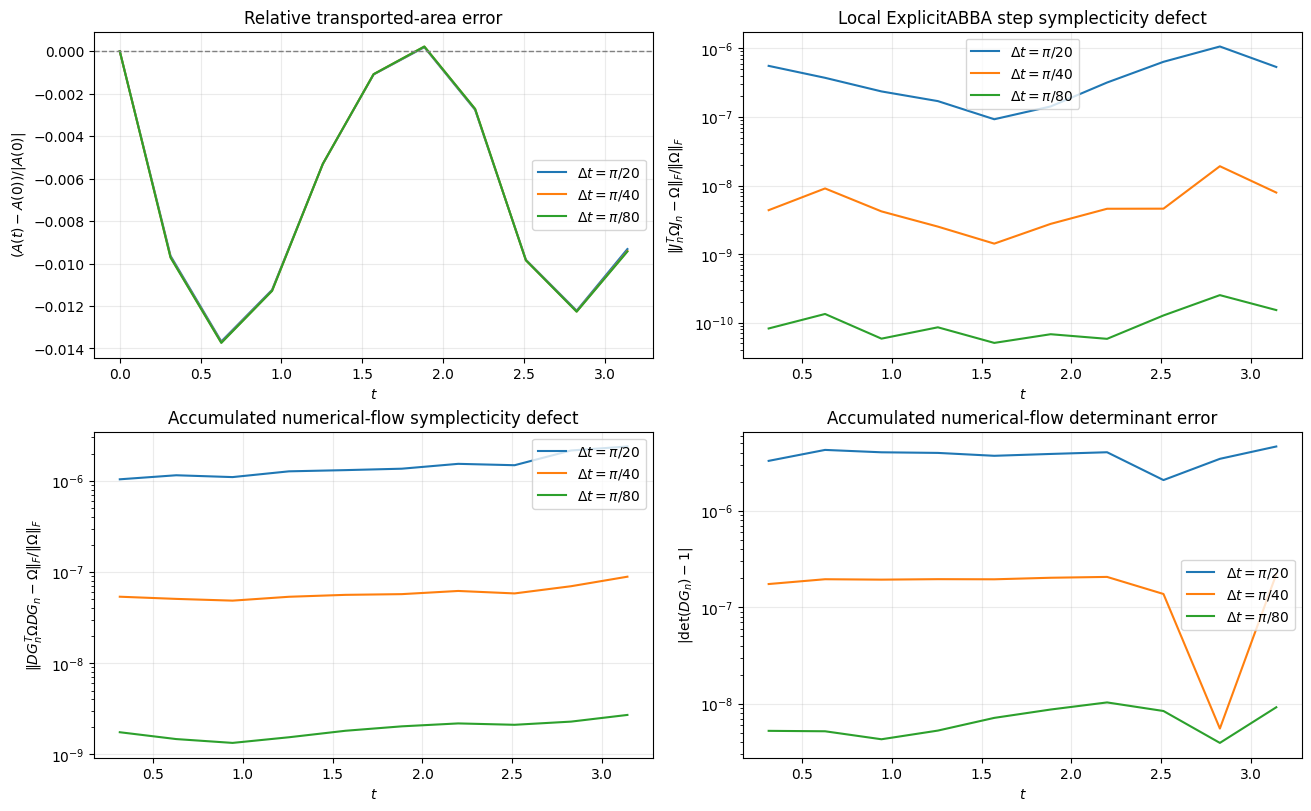

In [4]:
diagnostic_figure, diagnostic_axes = result.plot_diagnostics()

## Defect and copy-separation convergence

Unlike the symmetric-projected ABBA method, the explicit averaged map is not expected to reach only a numerical symplecticity floor. Its local and accumulated physical defects should decrease as the integration step is refined. The copy separation measures the size of the arithmetic projection applied at each step.

(ExplicitABBADefectOrder(coarse_label='$\\Delta t=\\pi/20$', fine_label='$\\Delta t=\\pi/40$', local_defect=5.795874883895077, flow_defect=4.7488332957116555, copy_separation=2.365004143504135),
 ExplicitABBADefectOrder(coarse_label='$\\Delta t=\\pi/40$', fine_label='$\\Delta t=\\pi/80$', local_defect=6.241080431346871, flow_defect=5.041878099891084, copy_separation=2.865136606423682))

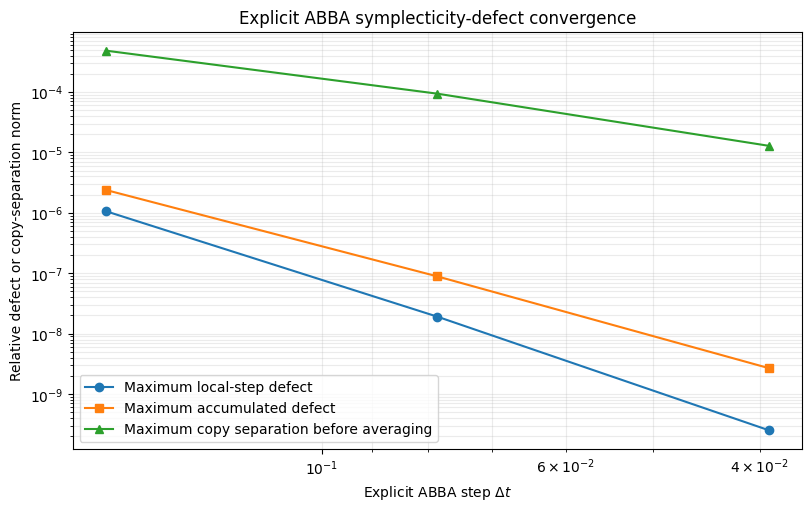

In [5]:
convergence_figure, convergence_axis = result.plot_convergence()
result.convergence_orders()

## Interpretation

The duplicated ABBA composition is symplectic in its extended space, but arithmetic averaging is rank-reducing there and does not transfer that guarantee to the physical map. The quadratic test case in `docs/tex/ABBA_explicit/ABBA_explicit.tex` makes the loss exact: $\det K_h-1=h^6/64$. The random-field experiment shows the same asymptotic structure: the measured local-defect orders are $5.80$ and $6.24$, while accumulation over $O(h^{-1})$ steps lowers the flow-defect orders to $4.75$ and $5.04$. The copy-separation orders, $2.37$ and $2.87$, approach the expected cubic scaling. The maximum flow defect falls from $2.39\times10^{-6}$ to $2.70\times10^{-9}$ across the three refinements. In contrast, the polygon-area error remains near $1.37\times10^{-2}$ because the eight-vertex spatial representation dominates this temporal refinement; it should not be interpreted as failure of the observed defect convergence.